# Morphological Operations in OpenCV

Morphology operates on **binary** (or grayscale) images using a **structuring element** (SE) — the morphological equivalent of a convolution kernel.

**Image sources:** synthetic binary mask, `skimage.data.coins`.

---

## 1. Structuring element (kernel)

The SE defines **shape and size** of the neighborhood:

| Shape | OpenCV constant | Typical use |
|-------|-----------------|-------------|
| Rectangle | `MORPH_RECT` | general purpose |
| Ellipse | `MORPH_ELLIPSE` | round objects |
| Cross | `MORPH_CROSS` | thin connections |

`cv2.getStructuringElement(shape, (w, h))`

---

## 2. Erosion (`cv2.erode`)

**What it does:** shrinks **foreground** (white) regions. A pixel stays white only if **all** SE-covered pixels are white.

| Effect | |
|--------|--|
| Removes small white specks | |
| Breaks thin bridges | |
| Shrinks object boundaries inward | |

---

## 3. Dilation (`cv2.dilate`)

**What it does:** expands foreground. A pixel becomes white if **any** SE-covered pixel is white.

| Effect | |
|--------|--|
| Fills small holes | |
| Connects nearby blobs | |
| Grows boundaries outward | |

---

## 4. Opening and closing

| Operation | Order | Removes | Fills |
|-----------|-------|---------|-------|
| **Opening** | erode → dilate | Small white noise (salt) | — |
| **Closing** | dilate → erode | — | Small black holes (pepper) |

`cv2.morphologyEx(src, cv2.MORPH_OPEN)` and `cv2.MORPH_CLOSE`

**Typical pipeline:** **opening first, then closing** — remove specks, then fill holes. Section 5 explains why the order matters.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from urllib.request import urlretrieve
import skimage.data as skid

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

NOTEBOOK_DIR = Path.cwd()
IMAGES_CACHE = NOTEBOOK_DIR.parent / "Images"
IMAGES_CACHE.mkdir(exist_ok=True)

ECE533_URLS = {
    "peppers": "https://homepages.cae.wisc.edu/~ece533/images/peppers.png",
    "boat": "https://homepages.cae.wisc.edu/~ece533/images/boat.png",
    "baboon": "https://homepages.cae.wisc.edu/~ece533/images/baboon.png",
}

SKIMAGE_FALLBACK = {
    "peppers": skid.astronaut,
    "boat": skid.camera,
    "baboon": skid.chelsea,
}


def load_sample_image(name):
    """Load from skimage.data or download Wisconsin ECE533 image (cached locally)."""
    skimg_map = {
        "camera": skid.camera,
        "coins": skid.coins,
        "astronaut": skid.astronaut,
        "coffee": skid.coffee,
        "chelsea": skid.chelsea,
        "page": skid.page,
    }
    if name in skimg_map:
        img = skimg_map[name]()
        if img.ndim == 2:
            return img.astype(np.uint8)
        return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    cache_path = IMAGES_CACHE / f"{name}.png"
    if cache_path.exists():
        img = cv2.imread(str(cache_path), cv2.IMREAD_UNCHANGED)
        if img is not None:
            return img

    url = ECE533_URLS.get(name)
    if url:
        try:
            print(f"Downloading {name} from ECE533 ...")
            urlretrieve(url, cache_path)
            img = cv2.imread(str(cache_path), cv2.IMREAD_UNCHANGED)
            if img is not None:
                return img
        except Exception as exc:
            print(f"Download failed ({exc}); using skimage fallback.")

    fallback = SKIMAGE_FALLBACK.get(name, skid.camera)
    img = fallback()
    if img.ndim == 2:
        return img.astype(np.uint8)
    return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)


def to_rgb(bgr):
    if bgr.ndim == 2:
        return bgr
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def show_gray(ax, img, title=""):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")


def show_rgb(ax, img_bgr, title=""):
    ax.imshow(to_rgb(img_bgr))
    ax.set_title(title)
    ax.axis("off")


def side_by_side(images, titles, rgb_flags=None, cols=5):
    """Plot a row/grid of images. images: list of arrays; rgb_flags: True for BGR color."""
    n = len(images)
    cols = min(cols, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows))
    axes = np.atleast_1d(axes).ravel()
    for i, (img, title) in enumerate(zip(images, titles)):
        is_rgb = rgb_flags[i] if rgb_flags else (img.ndim == 3)
        if is_rgb:
            show_rgb(axes[i], img, title)
        else:
            show_gray(axes[i], img, title)
    for j in range(n, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


def add_salt_pepper(gray, amount=0.05):
    """Inject salt-and-pepper noise into a uint8 grayscale image."""
    out = gray.copy()
    n = int(amount * gray.size)
    rng = np.random.default_rng(42)
    coords = (rng.integers(0, gray.shape[0], n), rng.integers(0, gray.shape[1], n))
    out[coords] = 255
    coords = (rng.integers(0, gray.shape[0], n), rng.integers(0, gray.shape[1], n))
    out[coords] = 0
    return out


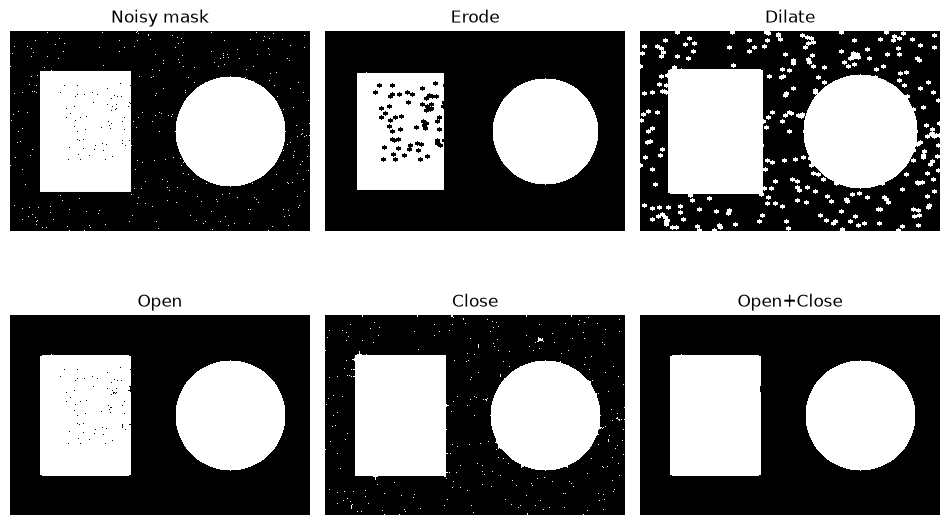

In [2]:
# Synthetic binary: shapes + salt noise + holes
rng = np.random.default_rng(0)
mask = np.zeros((200, 300), dtype=np.uint8)
cv2.rectangle(mask, (30, 40), (120, 160), 255, -1)
cv2.circle(mask, (220, 100), 55, 255, -1)
# Salt (white specks)
for _ in range(400):
    mask[rng.integers(0, 200), rng.integers(0, 300)] = 255
# Pepper holes inside rectangle
for _ in range(80):
    mask[rng.integers(50, 130), rng.integers(50, 140)] = 0

k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
eroded = cv2.erode(mask, k, iterations=1)
dilated = cv2.dilate(mask, k, iterations=1)
opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
clean = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, k)

side_by_side(
    [mask, eroded, dilated, opened, closed, clean],
    ["Noisy mask", "Erode", "Dilate", "Open", "Close", "Open+Close"],cols=3
)


## 5. Opening followed by closing — why this order?

Morphological cleanup on a binary mask is usually done in **two steps**:

$$\text{clean} = \text{close}(\text{open}(I))$$

### Step 1 — Opening (erode → dilate)

| Effect | |
|--------|--|
| Removes small white **salt** pixels on the background | |
| Breaks thin white bridges between objects | |
| Slightly **shrinks** objects (partly restored by dilate inside open) | |

### Step 2 — Closing (dilate → erode)

| Effect | |
|--------|--|
| Fills small black **holes** inside foreground objects | |
| Closes narrow gaps in white regions | |
| Slightly **expands** objects (erode in close pulls boundary back) | |

### Why open **before** close?

| Order | Problem |
|-------|---------|
| **Open → close** (recommended) | Salt removed first; closing only fills real holes in objects |
| **Close → open** | Closing can **connect** separate blobs or lock salt inside; opening may not undo that |

**Rule of thumb:** remove noise **outward** (open) before filling gaps **inward** (close).

Pipeline on real images: threshold → **open** → **close** → find contours.

Open removes salt, then close fills holes inside objects.


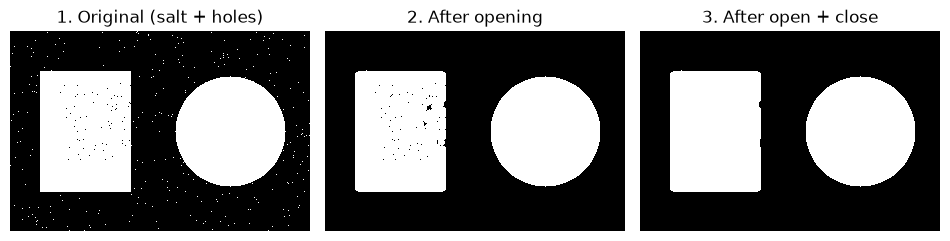

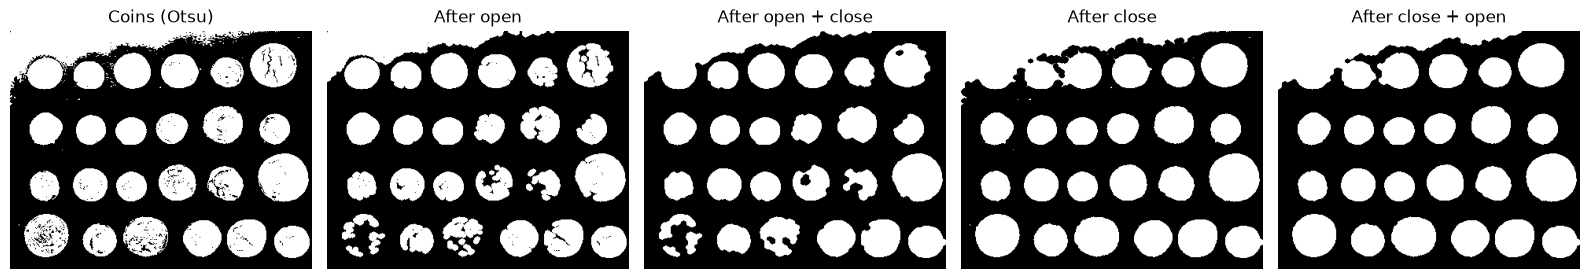

In [3]:
# Reuse noisy synthetic mask from section 2 (rebuild if running this cell alone)
if "mask" not in globals():
    rng = np.random.default_rng(0)
    mask = np.zeros((200, 300), dtype=np.uint8)
    cv2.rectangle(mask, (30, 40), (120, 160), 255, -1)
    cv2.circle(mask, (220, 100), 55, 255, -1)
    for _ in range(400):
        mask[rng.integers(0, 200), rng.integers(0, 300)] = 255
    for _ in range(80):
        mask[rng.integers(50, 130), rng.integers(50, 140)] = 0

k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

# Recommended: open then close
after_open = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
after_open_close = cv2.morphologyEx(after_open, cv2.MORPH_CLOSE, k)

print("Open removes salt, then close fills holes inside objects.")
side_by_side(
    [mask, after_open, after_open_close],
    [
        "1. Original (salt + holes)",
        "2. After opening",
        "3. After open + close",
    ],
)

# Coins: threshold then open + close
coins = load_sample_image("coins")
_, coins_bin = cv2.threshold(coins, 0, 255, cv2.THRESH_OTSU)
k7 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
coins_open = cv2.morphologyEx(coins_bin, cv2.MORPH_OPEN, k7)
coins_open_close = cv2.morphologyEx(coins_open, cv2.MORPH_CLOSE, k7)

coins_close = cv2.morphologyEx(coins_bin, cv2.MORPH_CLOSE, k7)
coins_close_open = cv2.morphologyEx(coins_close, cv2.MORPH_OPEN, k7)

side_by_side(
    [coins_bin, coins_open, coins_open_close, coins_close, coins_close_open],
    ["Coins (Otsu)", "After open", "After open + close", "After close", "After close + open"],
)

## 6. Structuring element shapes and sizes

Compare rectangle vs ellipse vs cross. Larger SE → stronger effect.


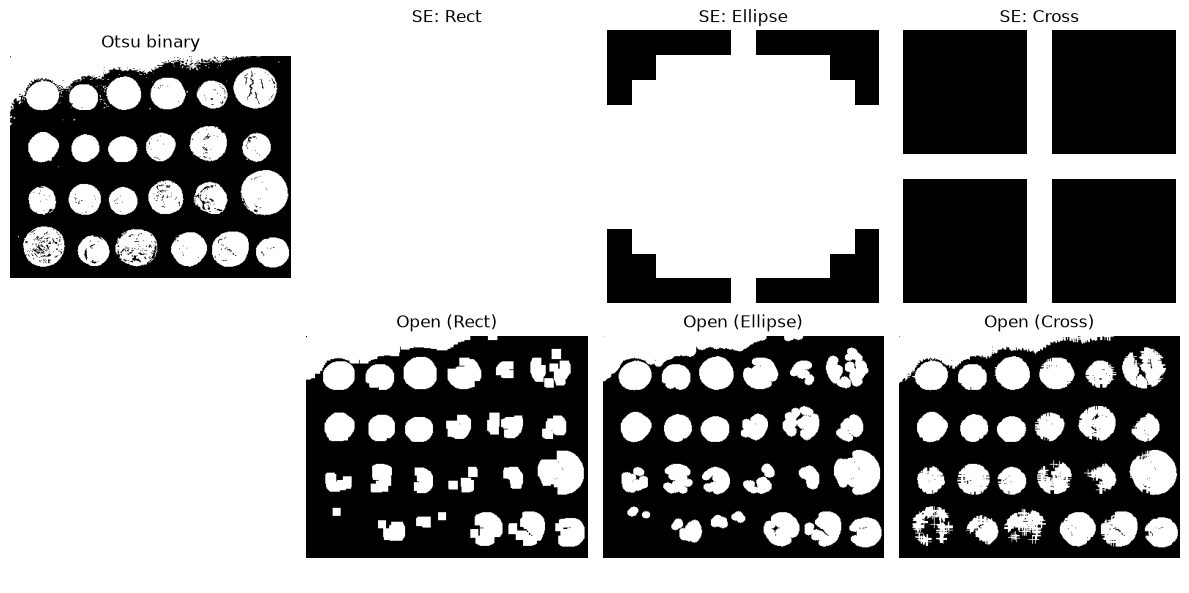

In [4]:
coins = load_sample_image("coins")
_, coins_bin = cv2.threshold(coins, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

shapes = [
    (cv2.MORPH_RECT, "Rect"),
    (cv2.MORPH_ELLIPSE, "Ellipse"),
    (cv2.MORPH_CROSS, "Cross"),
]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
show_gray(axes[0, 0], coins_bin, "Otsu binary")
for i, (shape, name) in enumerate(shapes):
    se = cv2.getStructuringElement(shape, (11, 11))
    show_gray(axes[0, i + 1], se * 255, f"SE: {name}")
    opened = cv2.morphologyEx(coins_bin, cv2.MORPH_OPEN, se)
    show_gray(axes[1, i + 1], opened, f"Open ({name})")
axes[1, 0].axis("off")
plt.tight_layout()
plt.show()


## 7. gradient, top-hat, black-hat

| Op | Formula | Use |
|----|---------|-----|
| Gradient | dilate − erode | object outlines |
| Top-hat | src − open | bright small features |
| Black-hat | close − src | dark small features |


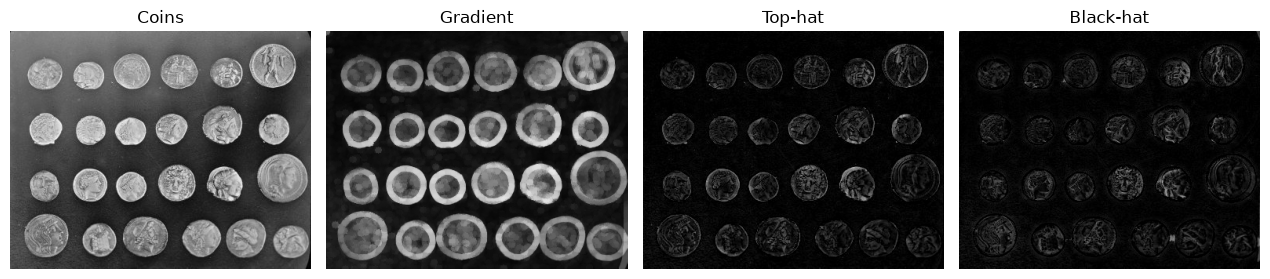

In [5]:
k5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
grad = cv2.morphologyEx(coins, cv2.MORPH_GRADIENT, k5)
tophat = cv2.morphologyEx(coins, cv2.MORPH_TOPHAT, k5)
blackhat = cv2.morphologyEx(coins, cv2.MORPH_BLACKHAT, k5)
side_by_side([coins, grad, tophat, blackhat], ["Coins", "Gradient", "Top-hat", "Black-hat"])


## 8. Summary

| Operation | Shrinks | Expands | Removes | Fills |
|-----------|---------|---------|---------|-------|
| Erode | ✓ | | white specks | |
| Dilate | | ✓ | | small gaps |
| Open | briefly | | salt | |
| Close | | briefly | | pepper / holes |
| **Open → close** | | | salt, then — | holes after salt is gone |
